<a href="https://colab.research.google.com/github/Halith0612/Ecotype-Forest-Cover-Classification---GUVI-Mini-Project-3/blob/Data-Collection-and-Cleaning/Ecotype1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# ***Mohamed Halith M K***
## **Title** : ***EcoType - Forest Cover Type Prediction Using Machine Learning***
### ***GUVI Mini Project- 3***
---

## Data Collection

In [44]:
# importing libraries
import pandas as pd
import numpy as np

In [45]:
forest_df = pd.read_csv(r"/content/drive/MyDrive/cover_type.csv") # read csv file

forest_df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [46]:
forest_df.tail()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
145885,2834,88,8,376,44,2552,232,227,128,1595,Lodgepole Pine,1,29
145886,2832,68,4,390,44,2522,224,231,142,1572,Lodgepole Pine,1,29
145887,2829,80,7,390,33,2492,229,228,133,1550,Lodgepole Pine,1,29
145888,2826,121,7,379,30,2462,232,234,135,1528,Lodgepole Pine,1,29
145889,2823,132,12,371,27,2432,239,234,123,1506,Lodgepole Pine,1,1


In [47]:
forest_df.shape

(145890, 13)

In [48]:
forest_df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [49]:
forest_df['Cover_Type'].unique()

array(['Aspen', 'Lodgepole Pine', 'Spruce/Fir', 'Krummholz',
       'Ponderosa Pine', 'Douglas-fir', 'Cottonwood/Willow'], dtype=object)

In [50]:
forest_df['Cover_Type'].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


# **Data Understanding**

In [51]:
print(forest_df.shape)

(145890, 13)


In [52]:
forest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [53]:
forest_df.describe() # summary stat

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [54]:
print(forest_df.nunique()) # find nunique values in all columns

Elevation                             1665
Aspect                                 361
Slope                                   60
Horizontal_Distance_To_Hydrology       435
Vertical_Distance_To_Hydrology         440
Horizontal_Distance_To_Roadways       5785
Hillshade_9am                          177
Hillshade_Noon                         144
Hillshade_3pm                          247
Horizontal_Distance_To_Fire_Points    5827
Cover_Type                               7
Wilderness_Area                          4
Soil_Type                               39
dtype: int64


In [55]:
# find unique values in all columns
for i in forest_df.columns:
  print(i)
  print(forest_df[i].unique())
  print("-"*55)

Elevation
[2596 2590 2804 ... 3504 3510 3604]
-------------------------------------------------------
Aspect
[ 51  56 139 155  45 132  49  59 201 151 134 214 157 259  72   0  38  71
 209 114  54  22 135 163 148 117 122 105 102  23  41 125  92  98 354 347
 346 330 128  68  94  99  66 100 323  79  81 315  74  11  42  75 107  90
  40  63  13  80 166   6  30 118 160 326 153 143 352  14 358 332  18 306
 173  31 164  34  84 170 211  32  57 348 333 324  88 111  53  58  76  17
 124 119 320 112  83   1  37 356 307   7  12 344 228 284 299 220   2  95
 289  21  20 200 349 328 221 257 276 196 189 130 357  15   8 288 129  28
  86 292 115  29 180 116  46 256 338 127 319  89  43 188  50 138 312   9
  10  36 167 260 187 279 245  27 359  16  48 149  60  77 230 152  70 325
 126 222 109  85  25 176 144 175 162  73  39  78 331 329 355  87 285 108
 106  24  52 261 232 246 342  61 141 216 236 254 336 278  62 237 281  69
 251 150 185 110 103 243 215 238 317 252 136 131 133 123 120 351 202 194
 101 282 258 27

In [56]:
for col in forest_df.columns:
    print(f"\nColumn: {col}")
    print(forest_df[col].value_counts())


Column: Elevation
Elevation
2972    1046
2968    1037
2991    1023
2978    1015
2975    1006
        ... 
3591       1
3604       1
2012       1
1978       1
2017       1
Name: count, Length: 1665, dtype: int64

Column: Aspect
Aspect
45     2627
90     1728
135    1660
0      1596
63     1087
       ... 
271      90
227      78
224      46
226      37
360       6
Name: count, Length: 361, dtype: int64

Column: Slope
Slope
10    10827
9     10173
8      9783
11     9781
12     9630
7      8784
13     8682
6      8000
14     7759
15     7013
5      6831
16     6003
4      5537
17     4746
18     4194
3      3696
19     3325
20     2792
2      2581
21     2246
22     2023
23     1730
24     1504
1      1401
25     1263
26     1083
27      874
28      730
29      568
30      424
31      392
32      312
0       244
33      229
34      199
35      148
36       99
37       86
38       50
39       42
41       22
40       21
46       18
42        6
49        5
45        5
44        5
47       

In [57]:
forest_df.isnull().sum() # find null values

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [58]:
forest_df.duplicated().sum() # find duplicates

np.int64(0)

In [59]:
# Finding Class Imbalance
for i in forest_df.columns:
  print(forest_df[i].value_counts(normalize=True) * 100)

Elevation
2972    0.716979
2968    0.710810
2991    0.701213
2978    0.695730
2975    0.689561
          ...   
3591    0.000685
3604    0.000685
2012    0.000685
1978    0.000685
2017    0.000685
Name: proportion, Length: 1665, dtype: float64
Aspect
45     1.800672
90     1.184454
135    1.137844
0      1.093975
63     0.745082
         ...   
271    0.061690
227    0.053465
224    0.031531
226    0.025362
360    0.004113
Name: proportion, Length: 361, dtype: float64
Slope
10    7.421345
9     6.973062
8     6.705737
11    6.704366
12    6.600864
7     6.020975
13    5.951059
6     5.483584
14    5.318391
15    4.807046
5     4.682295
16    4.114744
4     3.795325
17    3.253136
18    2.874769
3     2.533416
19    2.279114
20    1.913771
2     1.769141
21    1.539516
22    1.386661
23    1.185825
24    1.030914
1     0.960313
25    0.865721
26    0.742340
27    0.599081
28    0.500377
29    0.389334
30    0.290630
31    0.268696
32    0.213860
0     0.167249
33    0.156968
34    0.136

**Class distribution imbalance ratio**

|Ratio | Type               |
|------| -------------------|
|50:50 | Balanced           |
|60:40 | Mostly okay        |
|80:20 | worse → Imbalanced |
|95:5  | Highly imbalanced  |

**The biggest imbalance is in target column: Cover Type**
| Class             | Percentage |
| ----------------- | ---------- |
| Lodgepole Pine    | 70.65%     |
| Spruce/Fir        | 21.32%     |
| Aspen             | 2.10%      |
| Krummholz         | 1.48%      |
| Ponderosa Pine    | 1.48%      |
| Douglas-fir       | 1.48%      |
| Cottonwood/Willow | 1.48%      |

***This is a highly imbalanced multiclass dataset because***
  1. One class (Lodgepole Pine) dominates the dataset
  2. Several classes are below 2%
  3. Minority classes may be poorly predicted by ML models


# **Data Cleaning**

In [60]:
df1 = forest_df.copy() # I'm taking copy for data cleaning

df1.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [61]:
# find null values
print(df1.isnull().sum())

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64


**There are no nulls**

In [62]:
df1.duplicated().sum()# find duplicates

np.int64(0)

**There are no duplicates**

In [63]:
# finding outliers ----> using visuals; importing libraries for visuals
import matplotlib.pyplot as plt
import seaborn as sns

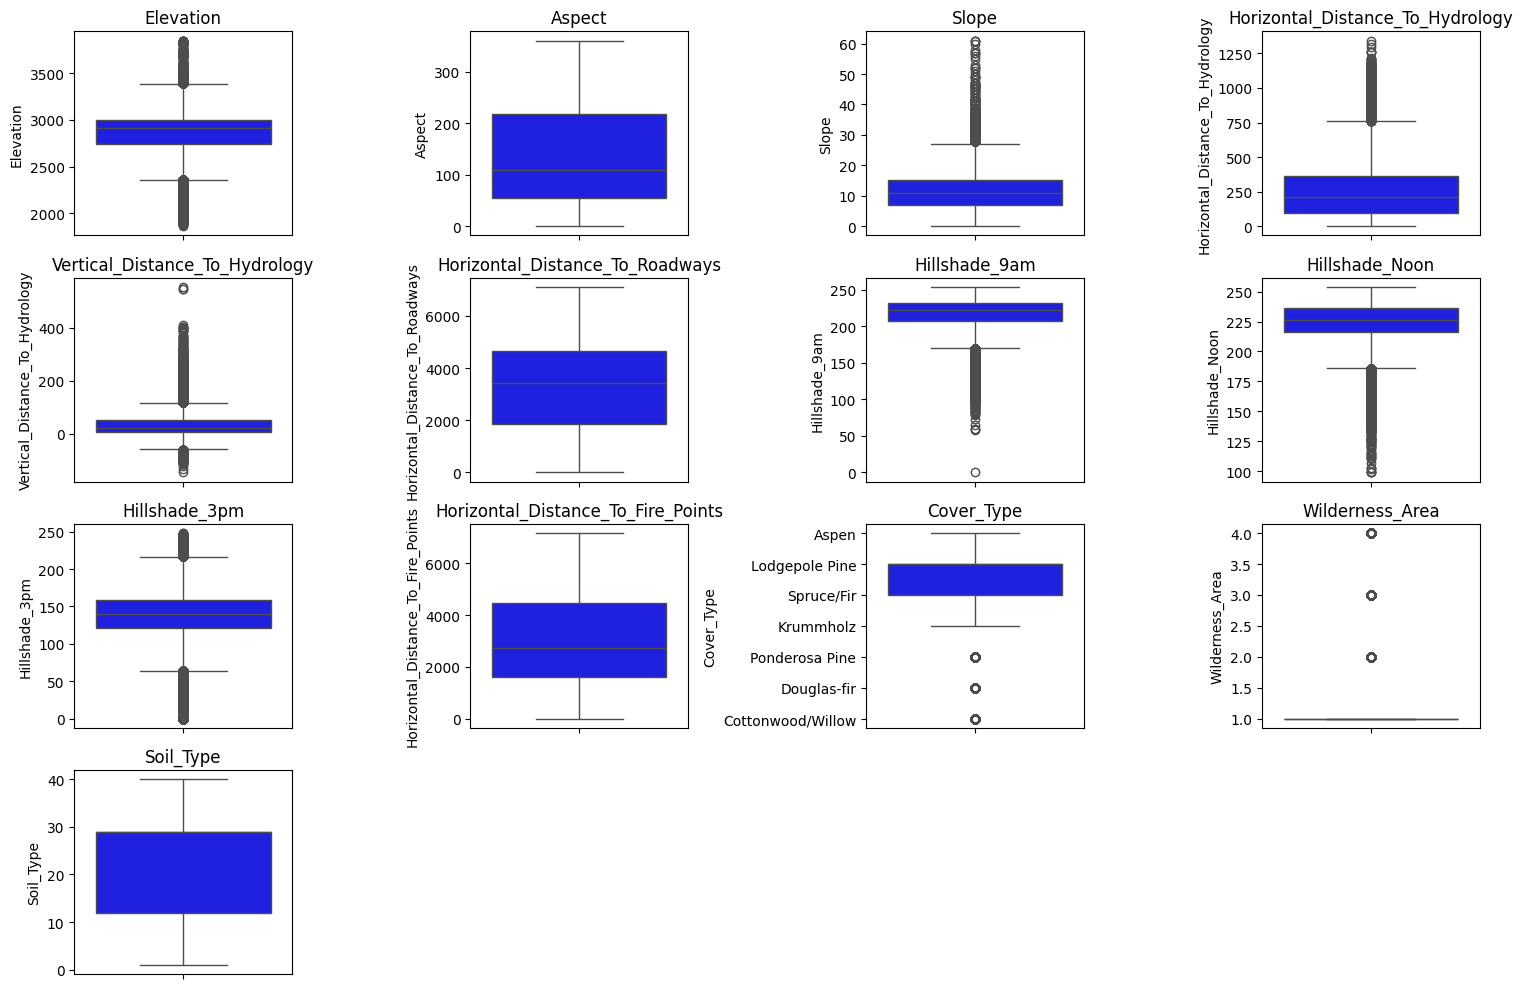

In [64]:
plt.figure(figsize=(15, 10)) # create fig --> size, width

for i, col in enumerate(df1.columns):
    plt.subplot(4, 4, i + 1) # create subplot:- potition ===> grid 4*4
    sns.boxplot(y=df1[col], color='blue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [65]:
numeric_cols = df1.select_dtypes(include='number').columns # taking numerical columns only

df_cleaned = df1.copy() # create separate dataframe for remove outliers


# outliers detection using IQR method
for col in numeric_cols:
  Q1 = df_cleaned[col].quantile(0.25) # 25% of values are below Q1.
  Q3 = df_cleaned[col].quantile(0.75) # 75% of values are below Q3.
  IQR = Q3 - Q1 # calulate IQR (Interquartile Range) 50% of values of data

  # define / setting outliers boundries
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # removing outliers in data
  df_cleaned = df_cleaned[
      (df_cleaned[col] >= lower_bound) &
      (df_cleaned[col] <= upper_bound)
  ]

# ensure outliers were removed
print("Original shape:", df1.shape)
print("After removing outliers:", df_cleaned.shape)

Original shape: (145890, 13)
After removing outliers: (119955, 13)


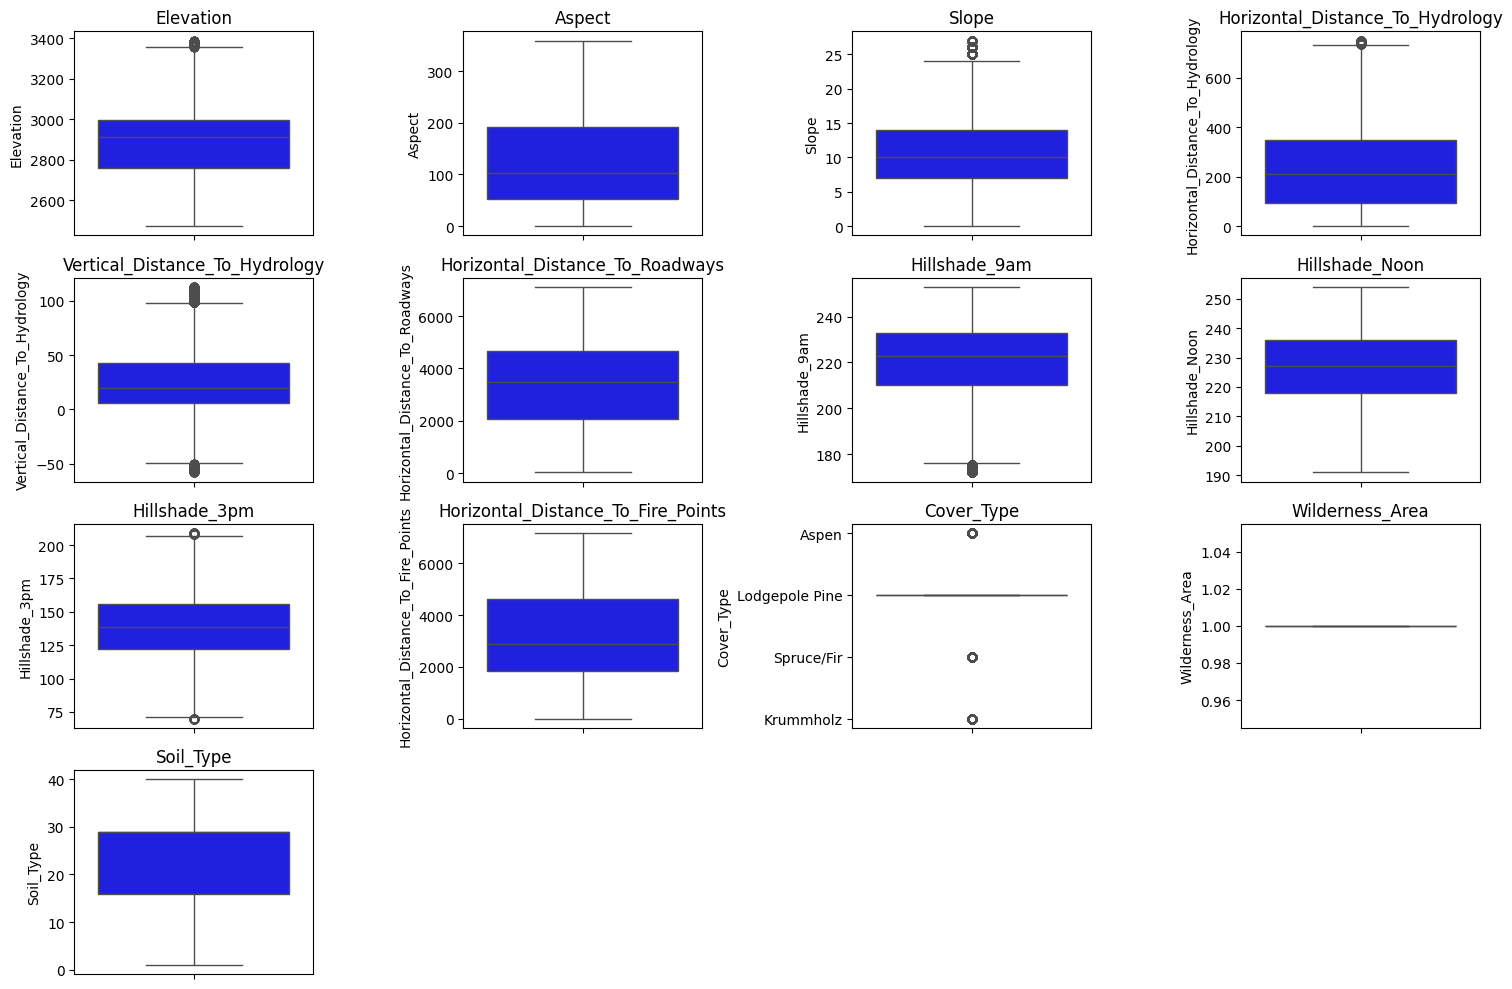

In [66]:
plt.figure(figsize=(15, 10)) # create fig --> size, width

for i, col in enumerate(df_cleaned.columns):
    plt.subplot(4, 4, i + 1) # create subplot:- potition ===> grid 4*4
    sns.boxplot(y=df_cleaned[col], color='blue')
    plt.title(col)

plt.tight_layout()
plt.show()

**Mager outliers were removed from dataset**

In [67]:
# Fix skewness in continuous variables using suitable transformations (e.g., log1p).
# Check skewness of numeric columns
skewness = df_cleaned.select_dtypes(include='number').skew()

# Sort by highest skewness
print(skewness.sort_values(ascending=False))

Aspect                                0.823726
Vertical_Distance_To_Hydrology        0.757943
Horizontal_Distance_To_Hydrology      0.678711
Slope                                 0.316817
Horizontal_Distance_To_Fire_Points    0.295874
Hillshade_3pm                         0.091391
Wilderness_Area                       0.000000
Horizontal_Distance_To_Roadways      -0.095538
Elevation                            -0.144639
Hillshade_Noon                       -0.237175
Soil_Type                            -0.641448
Hillshade_9am                        -0.648779
dtype: float64


**Skew**
1. Skewness > 1 → Highly positively skewed
2. Skewness < -1 → Highly negatively skewed
3. Between -1 and 1 → Usually acceptable

**Reault of Skew Test**
| Feature                            | Skewness | Interpretation              |
| ---------------------------------- | -------: | --------------------------- |
| Aspect                             |    0.824 | Moderately skewed           |
| Vertical_Distance_To_Hydrology     |    0.758 | Moderately skewed           |
| Horizontal_Distance_To_Hydrology   |    0.679 | Slightly skewed             |
| Slope                              |    0.317 | Low skew                    |
| Horizontal_Distance_To_Fire_Points |    0.296 | Low skew                    |
| Hillshade_3pm                      |    0.091 | Nearly symmetric            |
| Horizontal_Distance_To_Roadways    |   -0.096 | Nearly symmetric            |
| Elevation                          |   -0.145 | Nearly symmetric            |
| Hillshade_Noon                     |   -0.237 | Low skew                    |
| Soil_Type                          |   -0.641 | Categorical/encoded feature |
| Hillshade_9am                      |   -0.649 | Moderate negative skew      |

**Skewness analysis indicated no severe skewness (|skewness| > 1) in the continuous variables after preprocessing.**


In [70]:
df_cleaned.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29
5,2579,132,6,300,-15,67,230,237,140,6031,Lodgepole Pine,1,29


In [72]:
# convert cleaned dataset into .csv file for further preprocessing
df_cleaned.to_csv("/content/drive/MyDrive/df_cleaned.csv", index=False)